In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

os.makedirs("../charts", exist_ok=True)

sns.set_theme(style="whitegrid")

hi


In [3]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
cat = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
tx = pd.read_csv("../data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
cat["month"] = pd.to_datetime(cat["month"])
folio["month"] = pd.to_datetime(folio["month"])
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])

print("All datasets loaded successfully")

All datasets loaded successfully


In [4]:
nav_plot = nav.merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend for All 40 Schemes (2022–2026)"
)

fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.15, line_width=0)
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.12, line_width=0)

fig.write_image("../charts/01_nav_trend.png")
fig.show()

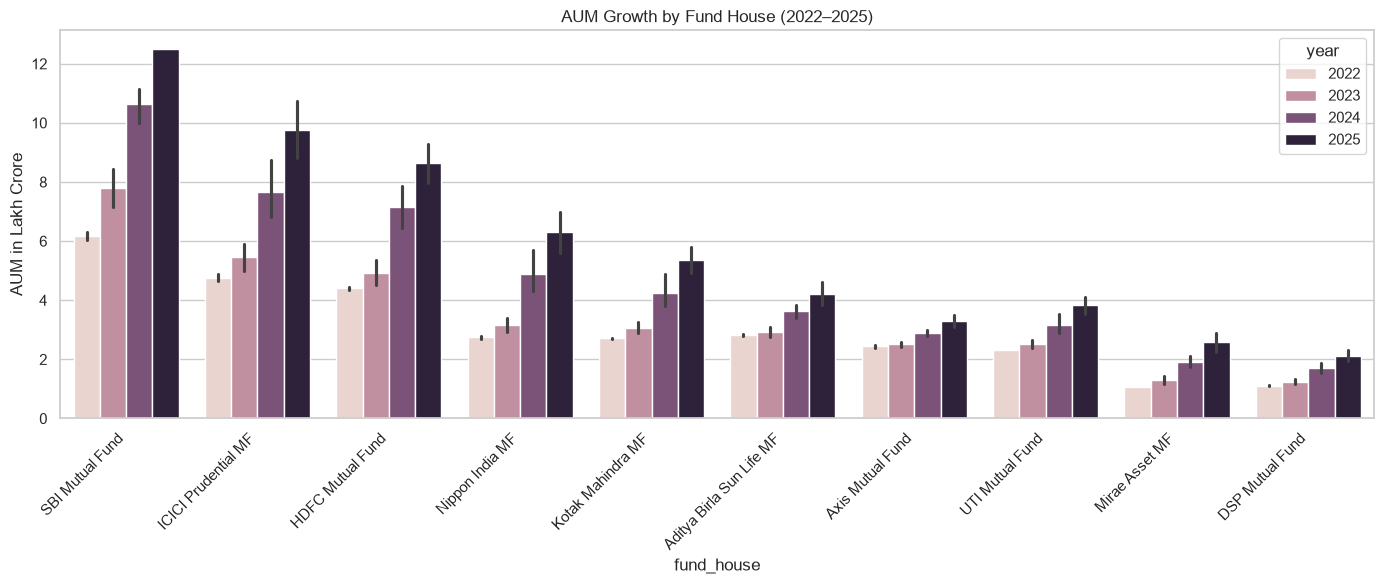

In [5]:
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14, 6))
sns.barplot(data=aum, x="fund_house", y="aum_lakh_crore", hue="year")
plt.xticks(rotation=45, ha="right")
plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM in Lakh Crore")
plt.tight_layout()
plt.savefig("../charts/02_aum_growth.png")
plt.show()

In [6]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr All-time High",
    showarrow=True,
    arrowhead=2
)

fig.write_image("../charts/03_sip_inflow_trend.png")
fig.show()

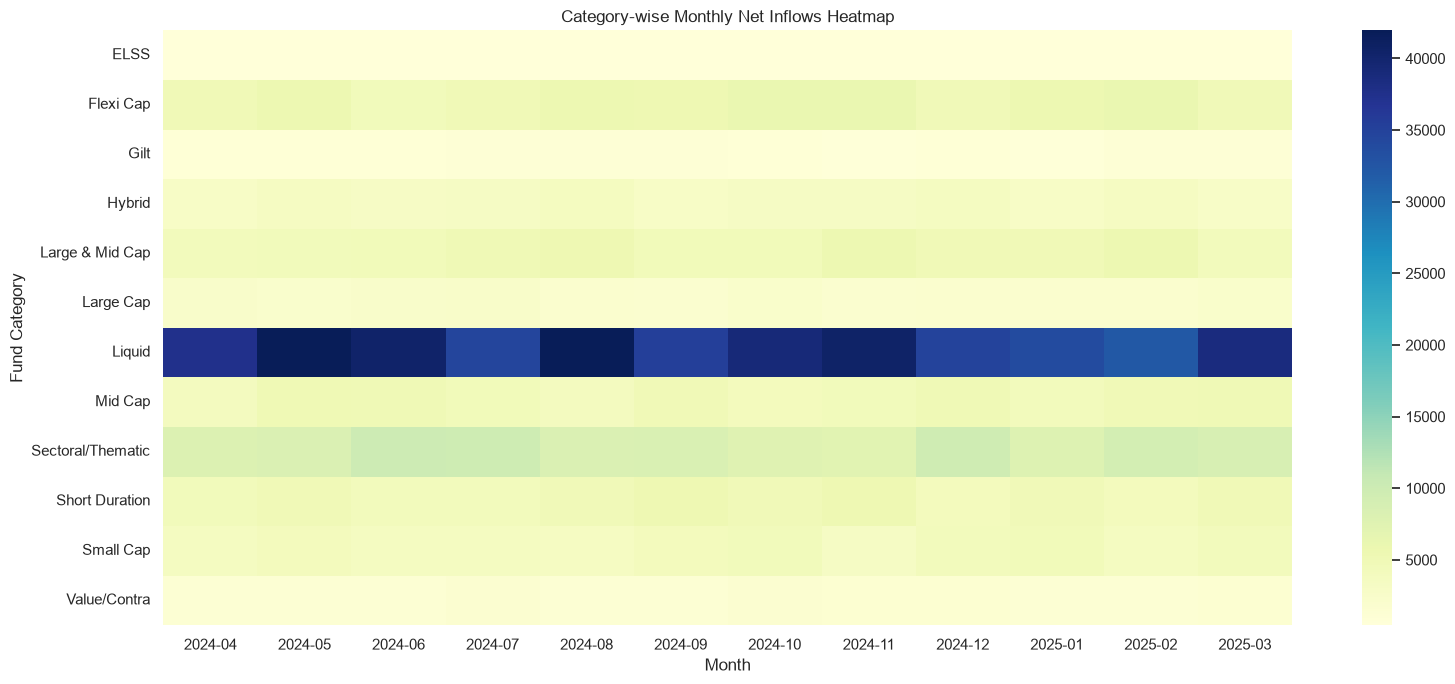

In [7]:
heatmap_data = cat.pivot_table(
    index="category",
    columns=cat["month"].dt.strftime("%Y-%m"),
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16, 7))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Category-wise Monthly Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig("../charts/04_category_heatmap.png")
plt.show()

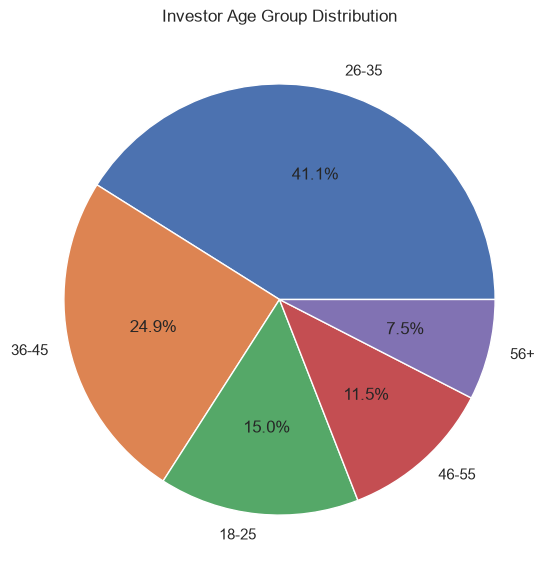

In [8]:
plt.figure(figsize=(7, 7))
tx["age_group"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.savefig("../charts/05_age_group_pie.png")
plt.show()

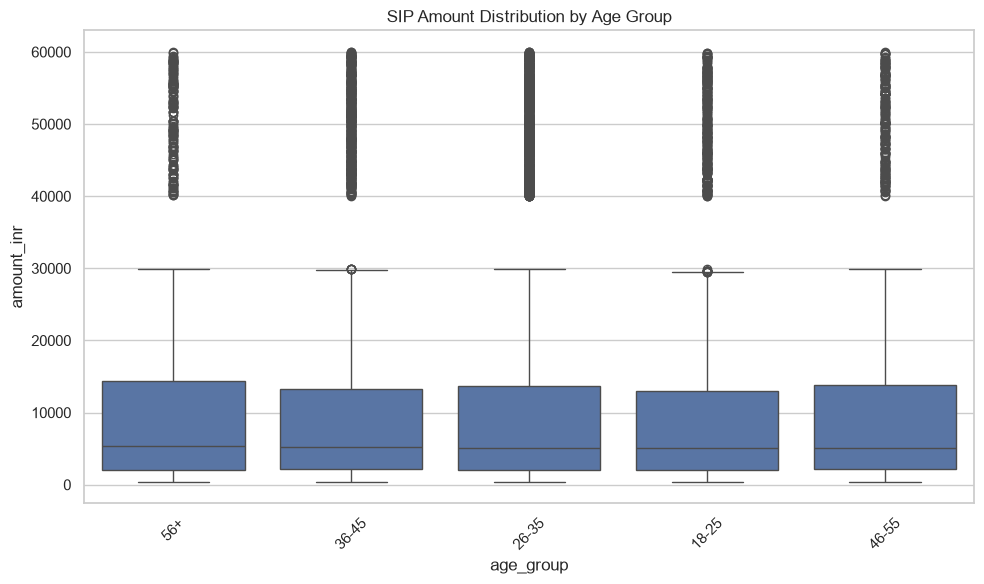

In [9]:
sip_tx = tx[tx["transaction_type"] == "SIP"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr")
plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/06_sip_amount_boxplot.png")
plt.show()

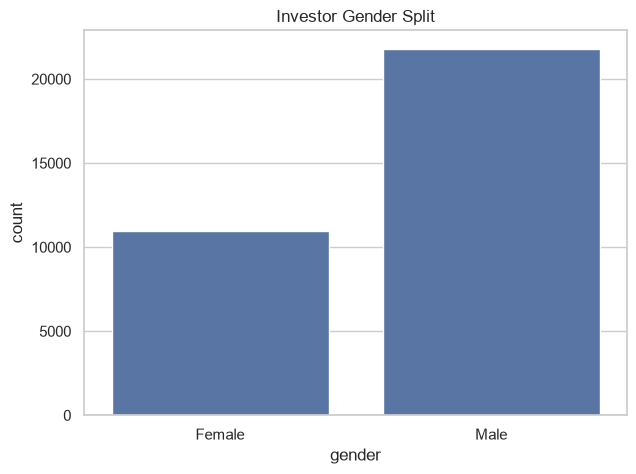

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=tx, x="gender")
plt.title("Investor Gender Split")
plt.savefig("../charts/07_gender_split.png")
plt.show()

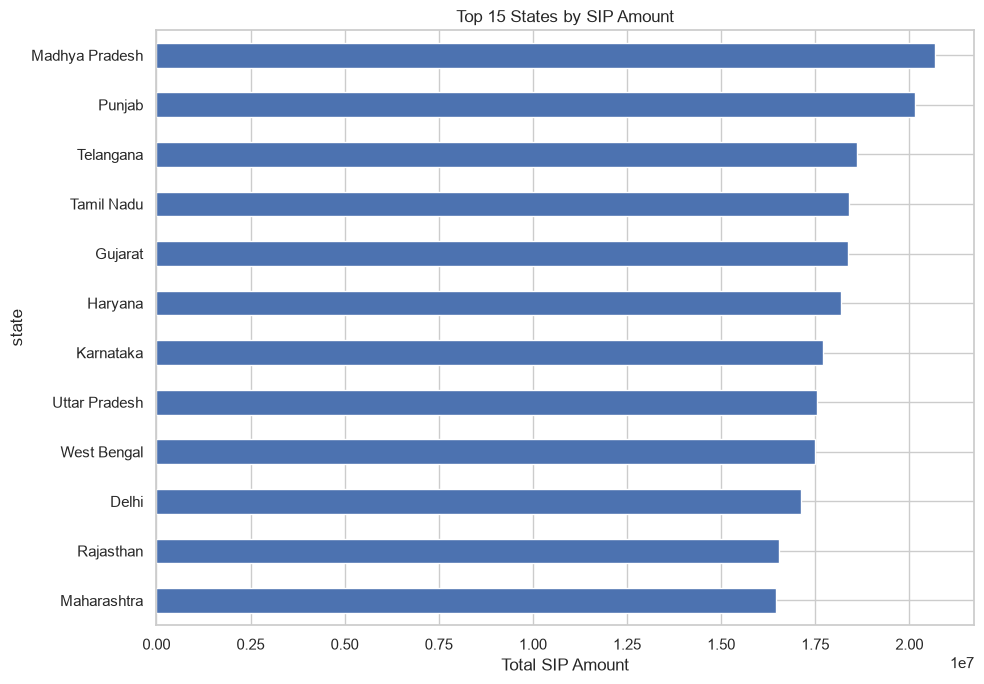

In [11]:
state_sip = sip_tx.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
state_sip.plot(kind="barh")
plt.title("Top 15 States by SIP Amount")
plt.xlabel("Total SIP Amount")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../charts/08_sip_by_state.png")
plt.show()

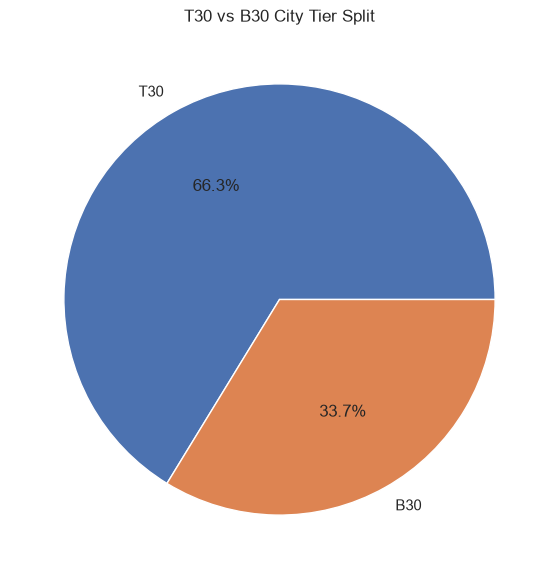

In [12]:
plt.figure(figsize=(7, 7))
tx["city_tier"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("T30 vs B30 City Tier Split")
plt.ylabel("")
plt.savefig("../charts/09_city_tier_pie.png")
plt.show()

In [13]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Folio Count Growth"
)

fig.add_annotation(x="2022-01-01", y=13.26, text="13.26 Cr", showarrow=True)
fig.add_annotation(x="2025-12-01", y=26.12, text="26.12 Cr", showarrow=True)

fig.write_image("../charts/10_folio_growth.png")
fig.show()

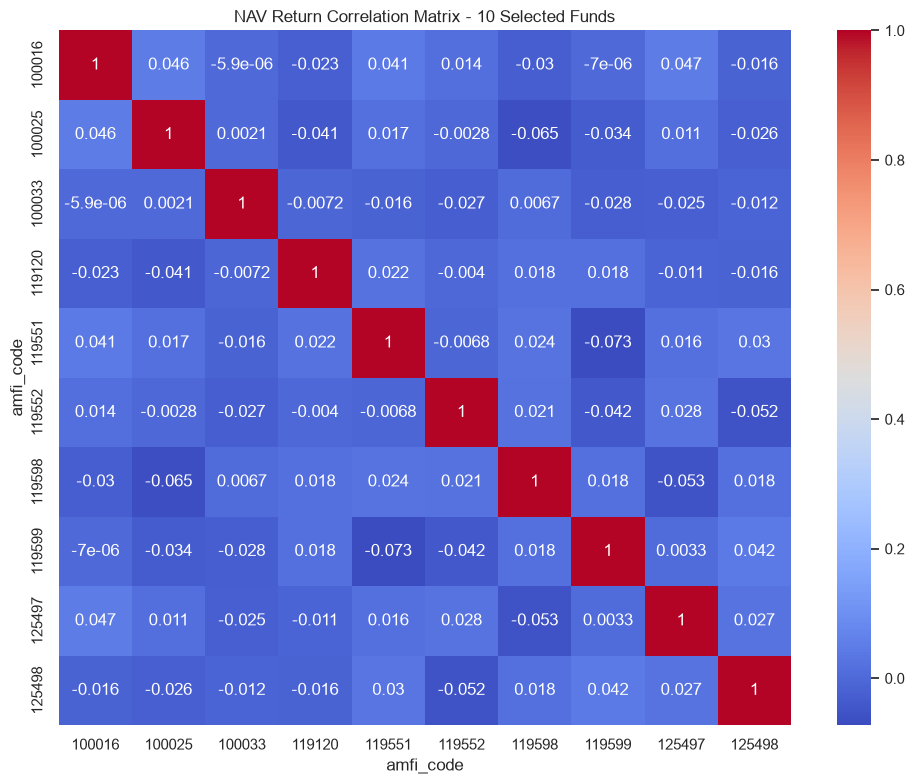

In [14]:
selected_codes = fund["amfi_code"].head(10).tolist()

nav_10 = nav[nav["amfi_code"].isin(selected_codes)]
nav_pivot = nav_10.pivot(index="date", columns="amfi_code", values="nav")
returns = nav_pivot.pct_change()

plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("NAV Return Correlation Matrix - 10 Selected Funds")
plt.tight_layout()
plt.savefig("../charts/11_nav_correlation.png")
plt.show()

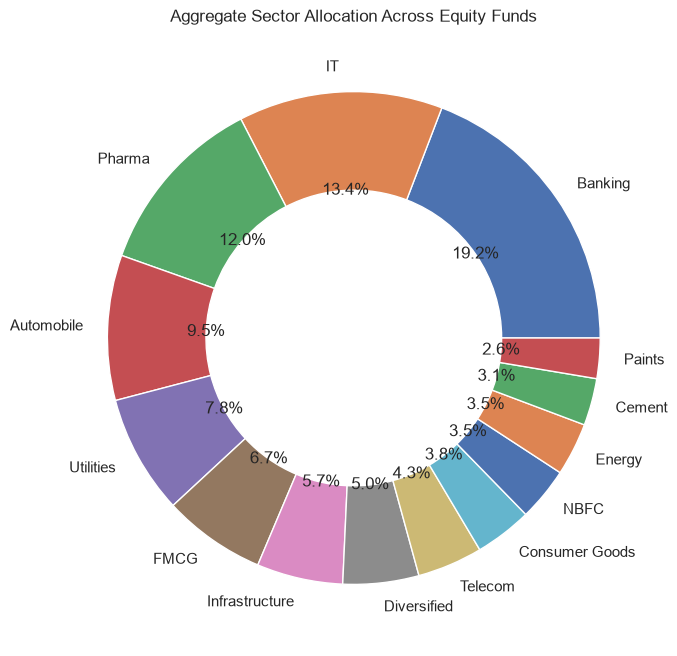

In [15]:
sector = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(sector, labels=sector.index, autopct="%1.1f%%", wedgeprops=dict(width=0.4))
plt.title("Aggregate Sector Allocation Across Equity Funds")
plt.savefig("../charts/12_sector_allocation_donut.png")
plt.show()

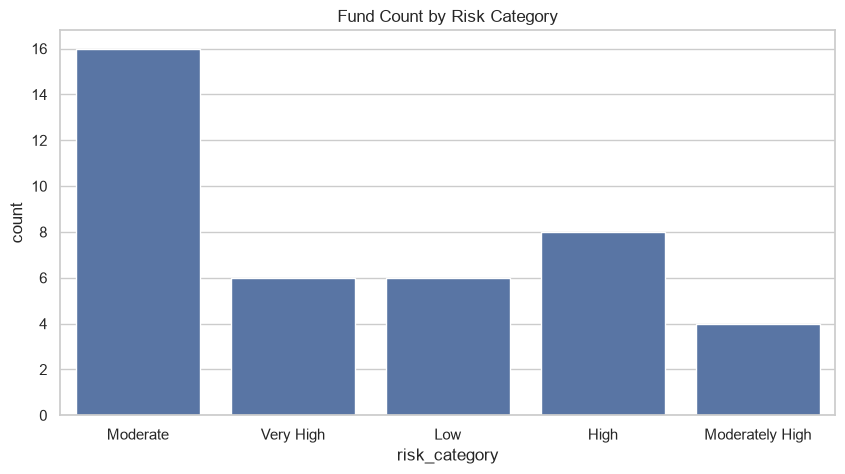

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(data=fund, x="risk_category")
plt.title("Fund Count by Risk Category")
plt.savefig("../charts/13_risk_category_count.png")
plt.show()

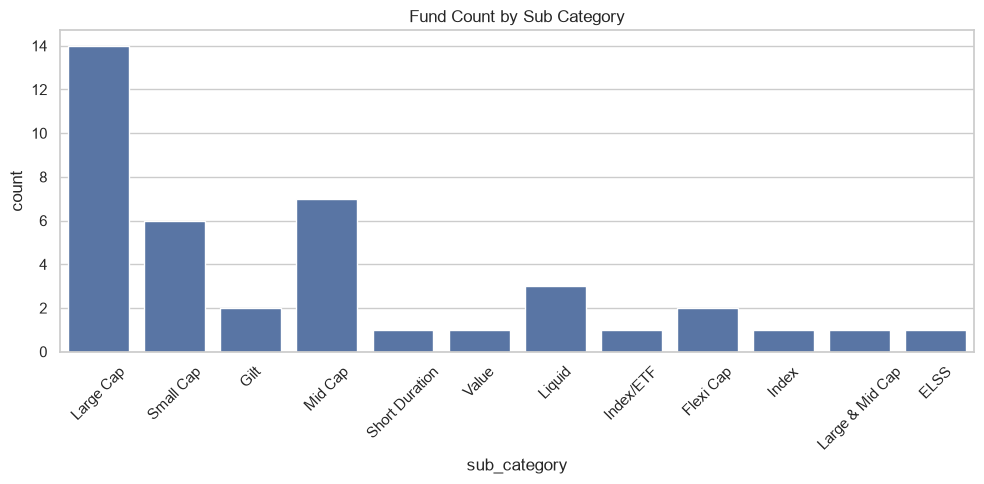

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=fund, x="sub_category")
plt.xticks(rotation=45)
plt.title("Fund Count by Sub Category")
plt.tight_layout()
plt.savefig("../charts/14_sub_category_count.png")
plt.show()

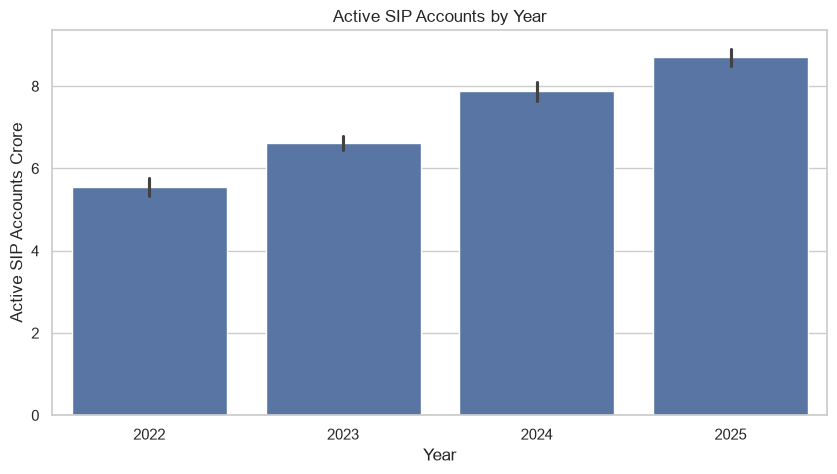

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=sip, x=sip["month"].dt.year, y="active_sip_accounts_crore")
plt.title("Active SIP Accounts by Year")
plt.xlabel("Year")
plt.ylabel("Active SIP Accounts Crore")
plt.savefig("../charts/15_active_sip_accounts.png")
plt.show()

In [ ]:
# 10 Key EDA Findings

1. NAV trends show visible growth during the 2023 bull run period.
2. NAV trends show correction phases during 2024 for several schemes.
3. SBI Mutual Fund shows strong AUM dominance among fund houses.
4. SIP inflows increased steadily from 2022 to 2025.
5. SIP inflow reached ₹31,002 crore in December 2025.
6. Equity categories show stronger inflow activity compared to debt-oriented categories.
7. Investor participation is distributed across multiple age groups.
8. SIP transaction amounts vary significantly by age group.
9. Geographic analysis shows that a few states contribute major SIP amounts.
10. Sector allocation shows concentration in selected sectors across equity fund portfolios.